# 09 — Forecast: Albania's Low-Proficiency Rate for the Next Cycle (2026)

After COVID delayed PISA 2021 to 2022, the assessment moved to a **4-year** cadence, so the next cycle is **2026**. Can we anticipate Albania's weighted low-proficiency (math < Level 2) rate? With only **five** cycles and a structural break in 2022 (the COVID spike), a single point extrapolation is indefensible — so we forecast with **transparent scenarios** and propagate each cycle's *design-based* uncertainty (the BRR + plausible-value SE from notebook 01) through a Monte-Carlo. Logic lives in `src/forecast/scenarios.py` (unit-tested); this notebook narrates.

> **Honesty note.** This is a *scenario* exercise, not a claim to predict a structural break. The value is the plausible range and the assumptions behind each edge, not a single number.

## Methods & formulas (reference)

**Why scenarios, not a point forecast.** Five cycles and a 2022 structural break
make any single extrapolation indefensible; we propagate the **design-based SE** of
each cycle (BRR + PV, notebook 01) through a Monte-Carlo and report **scenarios**.

**Monte-Carlo.** Draw each historical rate
$\tilde p_c\sim\mathcal{N}(\hat p_c,\ \text{SE}_c^2)$ over $N$ simulations, form each
scenario's next-cycle value per draw, and read off the median and the 5th/95th
percentiles (a 90% predictive interval).

**Scenarios.**
- **Persistence:** $p_{\text{next}}=p_{2022}+\varepsilon$ with a small drift SD
  (the crisis level holds).
- **Recovery:** the pre-COVID trend (weighted OLS line through 2009–2018) resumes,
  extrapolated forward (the 2022 spike fully reverses).
- **Partial:** the mean of persistence and recovery (the shock half-reverses).
- **Naïve linear** *(discarded):* a weighted line through **all five** cycles —
  shown only to demonstrate that ignoring the break manufactures false confidence.

The honest signal is the **width** of the plausible band, not a single number.

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
from src.features.target import add_all_targets
from src.data.weights import pv_statistic_brr
from src.forecast.scenarios import monte_carlo_forecast, scenarios_to_frame

df = add_all_targets(pd.read_parquet('../data/processed/albania_longitudinal.parquet'))
rows = []
for c in sorted(df.CYCLE.unique()):
    r = pv_statistic_brr(df[df.CYCLE==c], statistic='at_risk', domain='math')
    rows.append({'cycle': int(c), 'at_risk': r['estimate'], 'se': r['se'], 'brr': r['brr_available']})
hist = pd.DataFrame(rows)
hist

2026-07-03 12:17:55 [info     ] Point target added             at_risk_rate=0.602 domain=math threshold=420.07


2026-07-03 12:17:55 [info     ] Point target added             at_risk_rate=0.577 domain=reading threshold=407.47


2026-07-03 12:17:55 [info     ] Point target added             at_risk_rate=0.54 domain=science threshold=409.54


,cycle,at_risk,se,brr
0,2009,0.677346,0.007551,False
1,2012,0.606650,0.005063,False
2,2015,0.532830,0.010754,True
3,2018,0.423728,0.008813,True
4,2022,0.739431,0.004084,True


## 1. Scenario forecast for 2026

Three narratives + one reference:
- **persistence** — the 2022 crisis level holds.
- **recovery** — the pre-COVID improving trend (2009–2018) resumes (2022 fully reverses).
- **partial** — a 50/50 blend (the shock half-reverses).
- **naive_linear** *(reference)* — a weighted line through all five cycles; the 2022 break makes it meaningless, shown only to demonstrate why.

In [3]:
fc = monte_carlo_forecast(hist['cycle'].values, hist['at_risk'].values,
                          hist['se'].values, target_year=2026, n_sims=20000)
summary = scenarios_to_frame(fc, 2026)
summary.to_csv('../outputs/results/forecast_2026_scenarios.csv', index=False)
summary

,scenario,target_year,median,pi90_low,pi90_high
0,persistence,2026,0.7390,0.6569,0.8229
1,recovery,2026,0.2111,0.1833,0.2386
2,partial,2026,0.4750,0.4319,0.5193
3,naive_linear,2026,0.7299,0.7207,0.7392


## 2. Trajectory + scenario fan

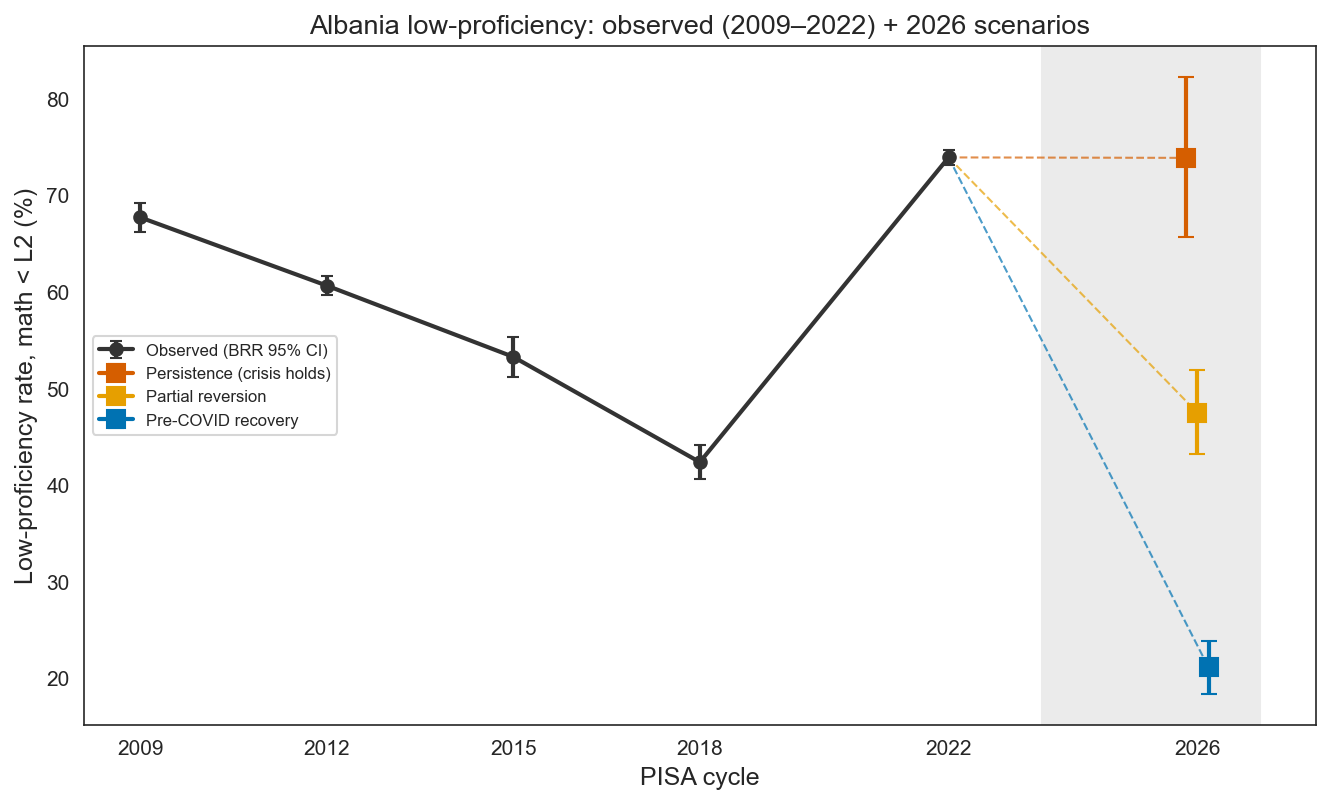

In [4]:
from src.visualization.style import apply_publication_style
apply_publication_style()
fig, ax = plt.subplots(figsize=(9, 5.5))
# historical line with 95% design-based error bars
ax.errorbar(hist['cycle'], hist['at_risk']*100, yerr=1.96*hist['se']*100,
            marker='o', lw=2, color='#333333', capsize=3, label='Observed (BRR 95% CI)')
colors = {'persistence':'#D55E00', 'partial':'#E69F00', 'recovery':'#0072B2'}
labels = {'persistence':'Persistence (crisis holds)',
          'partial':'Partial reversion', 'recovery':'Pre-COVID recovery'}
for i, name in enumerate(['persistence','partial','recovery']):
    s = fc[name]; xj = 2026 + (i-1)*0.18
    ax.errorbar([xj], [s.median*100],
                yerr=[[(s.median-s.lo)*100], [(s.hi-s.median)*100]],
                marker='s', ms=9, color=colors[name], capsize=4, lw=2, label=labels[name])
    # dashed connector from 2022 to the scenario median
    ax.plot([2022, xj], [hist['at_risk'].iloc[-1]*100, s.median*100],
            ls='--', lw=1, color=colors[name], alpha=0.7)
ax.axvspan(2023.5, 2027.0, color='0.92', zorder=0)
ax.set_xticks([2009,2012,2015,2018,2022,2026])
ax.set_xlabel('PISA cycle'); ax.set_ylabel('Low-proficiency rate, math < L2 (%)')
ax.set_title('Albania low-proficiency: observed (2009–2022) + 2026 scenarios')
ax.legend(fontsize=8, loc='center left'); plt.tight_layout(); plt.show()

## 3. Predictive densities

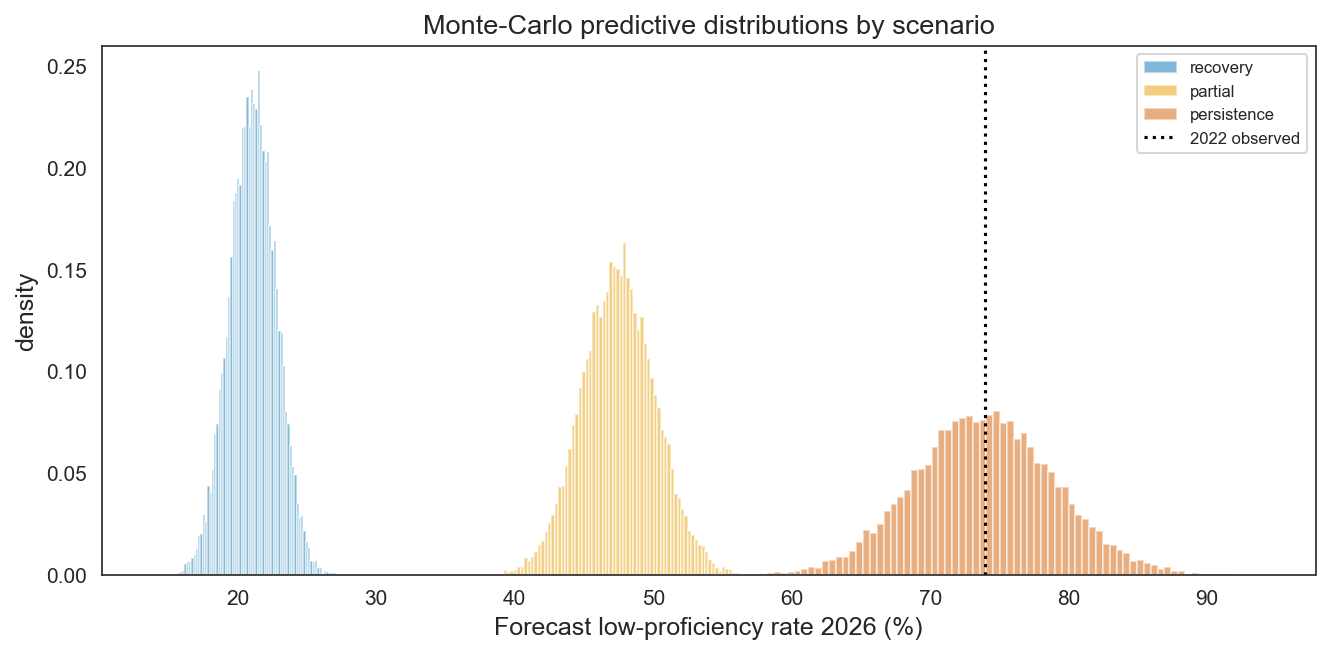

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
import numpy as np
for name in ['recovery','partial','persistence']:
    s = fc[name]
    ax.hist(s.samples*100, bins=80, density=True, alpha=0.5, color=colors[name], label=name)
ax.axvline(hist['at_risk'].iloc[-1]*100, color='k', ls=':', lw=1.5, label='2022 observed')
ax.set_xlabel('Forecast low-proficiency rate 2026 (%)'); ax.set_ylabel('density')
ax.set_title('Monte-Carlo predictive distributions by scenario'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Conclusions & Interpretation

- **Plausible 2026 range is wide: ~21% (full recovery) to ~74% (persistence).** With five cycles and a COVID break, that width is the honest message — not a single number.
- **Central expectation leans high.** The 2022 spike (74%) reflects durable disruptions (learning loss, teacher-support drop seen in notebook 03's covariate shift) unlikely to fully reverse by 2026, so the **partial-reversion (~47%) to persistence (~74%)** band is the more defensible zone; the ~21% *recovery* scenario assumes the pre-COVID trend resumes untouched and is best read as an optimistic floor.
- **The naive all-cycles line (~73%) is a trap** — it only looks confident (tight CI) because it ignores the structural break; shown to be discarded, not used.
- **Caveats:** the persistence drift SD is a judgment parameter; the recovery interval is narrow because it propagates only the four pre-COVID SEs, not model-form uncertainty — treat its precision with suspicion. Forecast is of the **aggregate** rate (no 2026 microdata exists); it is a planning aid, not a prediction of a break.
- **Policy read:** absent a strong, targeted recovery in school resources and teacher support (the notebook 03 drivers), Albania should plan for a 2026 low-proficiency rate still well above its 2018 low of 42%.